**Overview** The goal is to minimize the total electricity cost for meeting cooling demand for 8760 hours. It considers three main cooling sources: snow storage, a chilled water tank, and an electric chiller. It is formulated as Mixed-Integer Linear Programming (MILP) problem. There are eight decision variables and CBC solver for optimal values.


In [11]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
!pip install pulp

1. Cooling Demand

In [12]:
# specific cooling required in Estonian context
sp_cool = 70 # W/m2

# Building_Mall
Area_mall = 25000 # m2
load_mall = Area_mall * sp_cool

# Building_Hospital
Area_hospital = 35000 # m2
load_hospital = Area_hospital * sp_cool

# Building_School
Area_school = 20000 # m2
load_school = Area_school * sp_cool

# combining the cooling demand
total_load = load_mall + load_hospital + load_school
Q_gen_required = total_load/ 1000 # kW

print(f"Peak Cooling capacity: {Q_gen_required} kW")

Peak Cooling capacity: 5600.0 kW


2. Snow Storage

In [13]:
# Snow is stored in a thermally insulated pit
# setting the usage area (area constraint)
snow_pit_lg = 120  # m
snow_pit_wd = 80  # m
snow_pit_area =snow_pit_lg * snow_pit_wd

# snow properties
rho_snow = 750   # kg/m^3 (typical density)
enth_snow = 0.0926 # kWh/kg enthalpy of fusion
sp_cool_stored =  rho_snow * enth_snow # kWh/m3

# calculating the volume of the snow pit
snow_pit_ht = 8 # m
snow_pit_dp = 4 # m
alpha_deg = 45.0
beta_deg = 35.0

# Precompute common terms
tan_beta = np.tan(beta_deg)
tan_alpha = np.tan(alpha_deg)
sin_beta = np.sin(beta_deg)
sin_alpha = np.sin(alpha_deg)

# Volume calculations
term_surf = (snow_pit_lg - 2.0 * snow_pit_ht / tan_beta) * (snow_pit_wd - 2.0 * snow_pit_ht / tan_beta)
sqrt_surf = np.sqrt((snow_pit_lg * snow_pit_wd) * term_surf)
Vol_surf = (snow_pit_ht / 3.0) * ((snow_pit_lg * snow_pit_wd) + term_surf + sqrt_surf)

term_below = (snow_pit_lg - 2.0 * snow_pit_dp / tan_alpha) * (snow_pit_wd - 2.0 * snow_pit_dp / tan_alpha)
sqrt_below = np.sqrt((snow_pit_lg * snow_pit_wd) * term_below)
Vol_below = (snow_pit_dp / 3.0) * ((snow_pit_lg * snow_pit_wd) + term_below + sqrt_below)

vol_snowpit = Vol_below + Vol_surf

# energy capacity of the snow storage
energy_stored_ini = vol_snowpit *sp_cool_stored

# Cooling capacity of snow storage system (kW) i.e maximum value per hour.
snow_to_load_max = 2000

print(f"Snow Storage")
print(f"Volume of snow pit:  {vol_snowpit:.2f} m^3")
print(f"Cooling factor:      {sp_cool_stored:.2f} kWh/m^3")
print(f"Energy capacity:     {energy_stored_ini:.2f} kWh")

Snow Storage
Volume of snow pit:  89184.26 m^3
Cooling factor:      69.45 kWh/m^3
Energy capacity:     6193846.76 kWh


3. Chilled Water Tank

In [14]:
# sizing factor
autonomy_hours = 50.0

# Setting the temperature limits
T_tank_high = 17  # C
T_tank_low = 4   # C
delta_T_storage = T_tank_high - T_tank_low

rho_water = 999   # kg/m^3 (density at 10C)
cp_water = 4.184    # kJ/kg.K (specific heat)

# calculating the energy capacity of the storage tank
energy_stored_kWh = (Q_gen_required) * autonomy_hours # kWh
energy_stored_kJ = energy_stored_kWh * 3600

# calculating the volume of the storage tank
mass_storage = energy_stored_kJ / (cp_water * delta_T_storage)
volume_storage = mass_storage / rho_water

# calculating the design volume accounting for dead volume/piping & lossess
safety_factor = 1.5  # additional 50% of the tank capacity
volume_storage_design = volume_storage * safety_factor

# calculating the design tank capacity
TANK_VOLUME = volume_storage_design
TANK_CAPACITY_KWH = (TANK_VOLUME * rho_water * cp_water * delta_T_storage) / 3600

print(f" Chilled Water Tank ")
print(f"   - Desired Autonomy:   {autonomy_hours} Hours")
print(f"   - Useful Temp Range:  {T_tank_high}C to {T_tank_low}C")
print(f"   - Required Energy:    {energy_stored_kWh:.2f} kWh")
print(f"   - Design Volume:      {volume_storage_design:.2f} m^3")
print(f"   - Tank Capacity:      {TANK_CAPACITY_KWH:.2f} kWh")

 Chilled Water Tank 
   - Desired Autonomy:   50.0 Hours
   - Useful Temp Range:  17C to 4C
   - Required Energy:    280000.00 kWh
   - Design Volume:      27826.03 m^3
   - Tank Capacity:      420000.00 kWh


4. Backup Chiller

In [15]:
# Setting the temperature limits
T_chiller_evap = 280  # K ie 7 deg cel
T_chiller_cond = 308   # K i.e 35 deg cel
delta_T_chiller = T_chiller_cond - T_chiller_evap

# Calculating COP value for electric chiller
COP_Carnot = T_chiller_evap/delta_T_chiller
COP_Chiller = COP_Carnot * 0.55 # 45%–55% of the Carnot COP

chiller_max_thermal_output_per_hour = 0.5 * Q_gen_required # Assume chiller capacity is 50% of total cooling demand

print(f" Electric Chiller ")
print(f"  Carnot COP:   {COP_Carnot} unitless")
print(f"  Actual COP:   {COP_Chiller} unitless")
print(f"  Peak Chiller capacity:   {chiller_max_thermal_output_per_hour} kW")

 Electric Chiller 
  Carnot COP:   10.0 unitless
  Actual COP:   5.5 unitless
  Peak Chiller capacity:   2800.0 kW


5. Loading and Cleaning the Dataset

In [16]:
import pandas as pd

file_name = "New_Input_DataSet_Estonia-Tallinn.csv"

df_local = pd.read_csv(file_name, parse_dates=['Timestamp'], skiprows=[1], engine='python', encoding='iso-8859-1')
display(df_local.head())

# selecting the required columns
snow_volm_series = df_local.set_index('Timestamp')['SnowVolume']
total_load_series = df_local.set_index('Timestamp')['CoolingDemand']
ele_price_series = df_local.set_index('Timestamp')['ElectricPrice']

# checking for missing values in the data
snow_volm_series.isna().sum()
total_load_series.isna().sum()
ele_price_series.isna().sum()

# extracting the 8760 hours for the simulation
snow_volm_array = snow_volm_series.values[:8760]
total_load_array = total_load_series.values[:8760]
ele_price_array = ele_price_series.values[:8760]


/tmp/ipykernel_1107/3859054983.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_local = pd.read_csv(file_name, parse_dates=['Timestamp'], skiprows=[1], engine='python', encoding='iso-8859-1')


,Timestamp,SnowVolume,CoolingDemand,ElectricPrice
0,20230101:0011,95157.36,0,115.84
1,20230101:0111,95157.08,0,130.04
2,20230101:0211,95156.81,0,131.53
3,20230101:0311,95156.53,0,140.12
4,20230101:0411,95156.25,0,152.11


6. Main Simulation Loop

In [18]:
import numpy as np
from pulp import *

def solve_milp_resource_allocation(hours_to_optimize=8760):
    """
    Formulates and solves a Mixed-Integer Linear Programming (MILP) problem
    to optimize cooling resource allocation.

    The objective is to minimize total electricity cost while meeting cooling demand
    using snow storage, chilled water tank, and an electric chiller.

    Args:
        hours_to_optimize (int): The number of hours to include in the optimization horizon.

    Returns:
        dict or None: A dictionary of optimized results if the problem is solved optimally,
                      otherwise None.
    """

    print("Starting MILP problem formulation...")
    # Create the 'prob' variable to contain the problem data
    prob = LpProblem("Cooling_Resource_Allocation", LpMinimize)

    # Time horizon
    hours = np.arange(hours_to_optimize)

    # --- Decision Variables ---

    # Cooling supplied by different sources (kW) - Continuous
    x_snow_to_load = LpVariable.dicts("SnowToLoad", hours, lowBound=0, cat='Continuous')
    x_snow_to_tank = LpVariable.dicts("SnowToTank", hours, lowBound=0, cat='Continuous')
    x_tank_to_load = LpVariable.dicts("TankToLoad", hours, lowBound=0, cat='Continuous')
    x_chiller_to_load = LpVariable.dicts("ChillerToLoad", hours, lowBound=0, cat='Continuous')
    x_chiller_to_tank = LpVariable.dicts("ChillerToTank", hours, lowBound=0, cat='Continuous')

    # Grid electricity consumption (kW) - Continuous
    x_grid_power = LpVariable.dicts("GridPower", hours, lowBound=0, cat='Continuous')

    # Binary variable for chiller operation (on/off)
    y_chiller_on = LpVariable.dicts("ChillerOn", hours, cat='Binary')

    # Tank energy level (kWh) - Continuous
    # Lower bound 0, Upper bound TANK_CAPACITY_KWH
    s_tank_level = LpVariable.dicts("TankLevel", hours, lowBound=0, upBound=TANK_CAPACITY_KWH, cat='Continuous')

    print("Defining objective function...")
    # --- Objective Function ---
    # Minimize total electricity cost
    prob += lpSum(x_grid_power[h] * ele_price_array[h] for h in hours), "Total Electricity Cost"

    print("Adding constraints for each hour...")
    # --- Constraints ---

    # A sufficiently large number for Big M constraints
    M_chiller_power = chiller_max_thermal_output_per_hour * 1000 # Large enough to represent max possible power/thermal output
    M_tank_capacity = TANK_CAPACITY_KWH * 1000 # Large enough for tank level or charge/discharge
    M_load = np.max(total_load_array) * 1000

    for h in hours:
        # 1. Meet Cooling Demand at each hour
        prob += x_snow_to_load[h] + x_tank_to_load[h] + x_chiller_to_load[h] == total_load_array[h], f"MeetCoolingDemand_{h}"

        # 2. Snow Storage Constraints
        # Cooling from snow to load cannot exceed max discharge rate
        prob += x_snow_to_load[h] <= snow_to_load_max, f"SnowToLoadMaxLimit_{h}"
        # Cooling from snow to tank cannot exceed max discharge rate (assuming same limit)
        prob += x_snow_to_tank[h] <= snow_to_load_max, f"SnowToTankMaxLimit_{h}"
        # Total snow used (to load + to tank) cannot exceed available snow energy for this hour
        q_snow_therm_available_this_hour = (snow_volm_array[h] * sp_cool_stored)
        prob += x_snow_to_load[h] + x_snow_to_tank[h] <= q_snow_therm_available_this_hour, f"TotalSnowUsageLimit_{h}"

        # 3. Chiller Constraints
        # Chiller thermal output is linked to electrical input by COP
        prob += x_grid_power[h] * COP_Chiller == x_chiller_to_load[h] + x_chiller_to_tank[h], f"ChillerCOP_{h}"
        # Chiller total output cannot exceed its capacity if it's on
        prob += x_chiller_to_load[h] + x_chiller_to_tank[h] <= chiller_max_thermal_output_per_hour * y_chiller_on[h], f"ChillerCapacity_{h}"
        # Grid power is drawn only if chiller is on (using Big M)
        # If chiller is off (y_chiller_on[h] = 0), then x_grid_power[h] must be 0
        prob += x_grid_power[h] <= M_chiller_power * y_chiller_on[h], f"GridPowerChillerLink_{h}"

        # 4. Chilled Water Tank Constraints
        # Tank energy balance
        if h == 0:
            # Assuming tank starts empty at h=0
            prob += s_tank_level[h] == x_snow_to_tank[h] + x_chiller_to_tank[h] - x_tank_to_load[h], f"TankBalance_h0"
        else:
            prob += s_tank_level[h] == s_tank_level[h-1] + x_snow_to_tank[h] + x_chiller_to_tank[h] - x_tank_to_load[h], f"TankBalance_{h}"

        # Tank level must be within capacity (handled by variable bounds, but explicitly here for clarity if bounds change)
        prob += s_tank_level[h] <= TANK_CAPACITY_KWH, f"TankLevelMax_{h}"
        prob += s_tank_level[h] >= 0, f"TankLevelMin_{h}"

        # Tank charge from chiller or snow cannot exceed the maximum tank capacity (in a single hour)
        prob += x_chiller_to_tank[h] <= TANK_CAPACITY_KWH, f"ChillerTankChargeMax_{h}"
        prob += x_snow_to_tank[h] <= TANK_CAPACITY_KWH, f"SnowTankChargeMax_{h}"

    print("Solving MILP problem... (This may take some time for 8760 hours)")
    # Solve the problem
    # The default solver is CBC, which is usually included with PuLP and works well.
    prob.solve()

    # --- Extract Results ---
    if LpStatus[prob.status] == "Optimal":
        print("MILP Problem Status: Optimal")
        total_cost = value(prob.objective)
        print(f"Optimal Total Electricity Cost: {total_cost:.2f} EUR")

        # Store results for analysis
        results = {
            'total_cost_eur': total_cost,
            'snow_to_load_kW': [x_snow_to_load[h].varValue for h in hours],
            'tank_to_load_kW': [x_tank_to_load[h].varValue for h in hours],
            'chiller_to_load_kW': [x_chiller_to_load[h].varValue for h in hours],
            'grid_power_kW': [x_grid_power[h].varValue for h in hours],
            'chiller_on_binary': [y_chiller_on[h].varValue for h in hours],
            'tank_level_kWh': [s_tank_level[h].varValue for h in hours],
            'snow_to_tank_kW': [x_snow_to_tank[h].varValue for h in hours],
            'chiller_to_tank_kW': [x_chiller_to_tank[h].varValue for h in hours],
        }

        # Calculate some summary KPIs
        total_load_MWh = sum(total_load_array)/1000
        total_grid_MWh = sum(results['grid_power_kW'])/1000
        total_snow_to_load_MWh = sum(results['snow_to_load_kW'])/1000
        total_chiller_to_load_MWh = sum(results['chiller_to_load_kW'])/1000
        total_tank_delivered_MWh = sum(results['tank_to_load_kW'])/1000

        results['total_load_MWh'] = total_load_MWh
        results['total_grid_MWh'] = total_grid_MWh
        results['total_snow_to_load_MWh'] = total_snow_to_load_MWh
        results['total_chiller_to_load_MWh'] = total_chiller_to_load_MWh
        results['total_tank_delivered_MWh'] = total_tank_delivered_MWh

        snow_tank_contribution = total_snow_to_load_MWh + total_tank_delivered_MWh
        snow_fraction = (snow_tank_contribution / total_load_MWh) * 100 if total_load_MWh > 0 else 0
        results['snow_tank_contribution_percentage'] = snow_fraction

        return results
    else:
        print(f"MILP Problem Status: {LpStatus[prob.status]}")
        print("No optimal solution found.")
        return None

# Run the MILP solver
milp_results = solve_milp_resource_allocation(hours_to_optimize=8760)

# Technical Summary
print("\n--- Optimization Summary ---")
print(f"Total Electricity Cost: {milp_results['total_cost_eur']:.2f} EUR")
print(f"Total Cooling Load: {milp_results['total_load_MWh']:.2f} MWh")
print(f"Total Grid Electricity Used: {milp_results['total_grid_MWh']:.2f} MWh")
print(f"Snow + Tank Contribution to Load: {milp_results['snow_tank_contribution_percentage']:.2f}%")


Starting MILP problem formulation...
Defining objective function...
Adding constraints for each hour...
Solving MILP problem... (This may take some time for 8760 hours)
MILP Problem Status: Optimal
Optimal Total Electricity Cost: -208798.55 EUR

--- Optimization Summary ---
Total Electricity Cost: -208798.55 EUR
Total Cooling Load: 2378.75 MWh
Total Grid Electricity Used: 104.17 MWh
Snow + Tank Contribution to Load: 97.28%


7. Visualisation

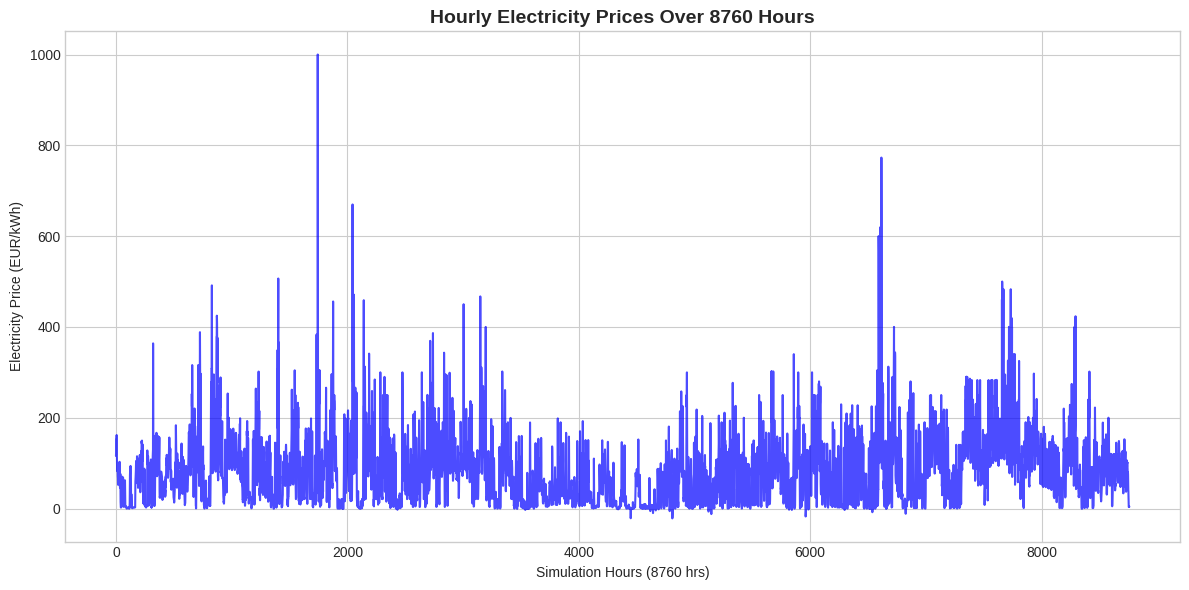

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(np.arange(len(ele_price_array)), ele_price_array, color='blue', alpha=0.7)

ax.set_title('Hourly Electricity Prices Over 8760 Hours', fontsize=14, fontweight='bold')
ax.set_xlabel('Simulation Hours (8760 hrs)')
ax.set_ylabel('Electricity Price (EUR/kWh)')
ax.grid(True)

plt.tight_layout()
plt.show()

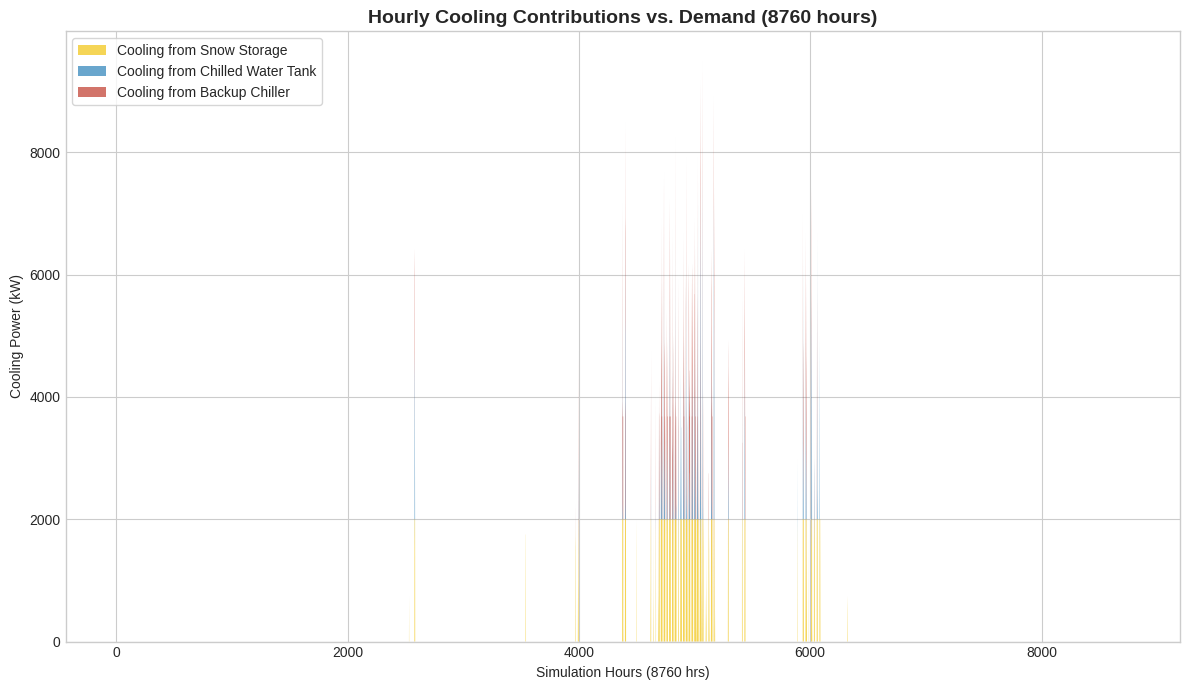

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you want to visualize the dynamic dispatch results.
# If you wanted static, you'd use 'static_results'.
# Make sure dynamic_results is available in the kernel (i.e., cell e093f945 has been run).

# Retrieve results from the dynamic_results dictionary
hours = np.arange(8760) # Ensure hours array is available for plotting x-axis
results_snow_used = dynamic_results['results_snow_used']
results_tank_level = dynamic_results['results_tank_level']
results_chiller_used_thermal = dynamic_results['results_chiller_used_thermal']

# Calculate the hourly cooling delivered by the tank
# A positive change in results_tank_level means the tank charged, a negative change means it discharged.
# We are interested in discharge, so we take the negative of the change when it's negative.
delta_tank_level = np.diff(results_tank_level, prepend=results_tank_level[0])
hourly_tank_discharge = np.maximum(0, -delta_tank_level)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Stacked area plot for contributions
ax.stackplot(
    hours,
    results_snow_used,
    hourly_tank_discharge,
    results_chiller_used_thermal,
    labels=['Cooling from Snow Storage', 'Cooling from Chilled Water Tank', 'Cooling from Backup Chiller'],
    colors=['#F1C40F', '#2980B9', '#C0392B'],
    alpha=0.7
)

ax.set_title('Hourly Cooling Contributions vs. Demand (8760 hours)', fontsize=14, fontweight='bold')
ax.set_xlabel('Simulation Hours (8760 hrs)')
ax.set_ylabel('Cooling Power (kW)')
ax.legend(loc='upper left', frameon=True)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
ax.grid(True)

plt.tight_layout()
plt.show()